In [1]:
import pandas as pd
df = pd.read_csv('../data/payment_fraud_2025.csv')

In [2]:
print(df.columns.tolist())

['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Time', 'Customer_Age', 'Customer_Loyalty_Tier', 'Location', 'Store_ID', 'Product_SKU', 'Product_Category', 'Purchase_Amount', 'Payment_Method', 'Device_Type', 'IP_Address', 'Fraud_Flag', 'Footfall_Count']


In [3]:
print("Dataset Shape:", df.shape)
df.info()




Dataset Shape: (2133, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         2133 non-null   str    
 1   Customer_ID            2133 non-null   str    
 2   Transaction_Date       2133 non-null   str    
 3   Transaction_Time       2133 non-null   str    
 4   Customer_Age           2027 non-null   float64
 5   Customer_Loyalty_Tier  2027 non-null   str    
 6   Location               2133 non-null   str    
 7   Store_ID               2133 non-null   str    
 8   Product_SKU            2133 non-null   str    
 9   Product_Category       2133 non-null   str    
 10  Purchase_Amount        2133 non-null   float64
 11  Payment_Method         2027 non-null   str    
 12  Device_Type            2133 non-null   str    
 13  IP_Address             2133 non-null   str    
 14  Fraud_Flag             2133 non-null   in

## Preprocessing Pipeline Completeness 
### Data Split, Structural Feature Drops, Median/Mode Imputation and One-Hot Encoding


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# 1. LOAD DATA & AUTO-DETECT COLUMNS

target_col = 'Fraud_Flag'

# Drop tracking/ID columns that shouldn't be used at all
drop_cols = ['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Time', 'IP_Address']
X = df.drop(columns=[col for col in drop_cols + [target_col] if col in df.columns])
y = df[target_col]

# AUTOMATIC DETECTION: Find text vs numeric columns instantly
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print(f"Automatically detected Numerical columns: {numerical_cols}")
print(f"Automatically detected Categorical columns: {categorical_cols}\n")


# 2. STRATIFIED TRAIN-TEST SPLIT (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


# 3. COMPREHENSIVE PREPROCESSING PIPELINE

# Pipeline for numbers: Impute missing entries with the stable Median

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline for strings: Impute with Most Frequent value, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Use remainder='drop' to make sure no loose string columns accidentally slip through
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop' 
)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


Automatically detected Numerical columns: ['Customer_Age', 'Purchase_Amount', 'Footfall_Count']
Automatically detected Categorical columns: ['Customer_Loyalty_Tier', 'Location', 'Store_ID', 'Product_SKU', 'Product_Category', 'Payment_Method', 'Device_Type']



##  Baseline & Advanced Model Implementation
### Performance Comparison: Linear Baseline vs. Tree-Based Ensemble

In [5]:

# 4. MODEL 1: Logistic Regression (Baseline)

print("Training Baseline Model (Logistic Regression)...")
baseline_model = LogisticRegression(random_state=42, max_iter=2000)
baseline_model.fit(X_train_processed, y_train)
y_pred_baseline = baseline_model.predict(X_test_processed)


# 5. MODEL 2: Random Forest (Advanced Model)

print("Training Advanced Model (Random Forest)...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)


Training Baseline Model (Logistic Regression)...
Training Advanced Model (Random Forest)...


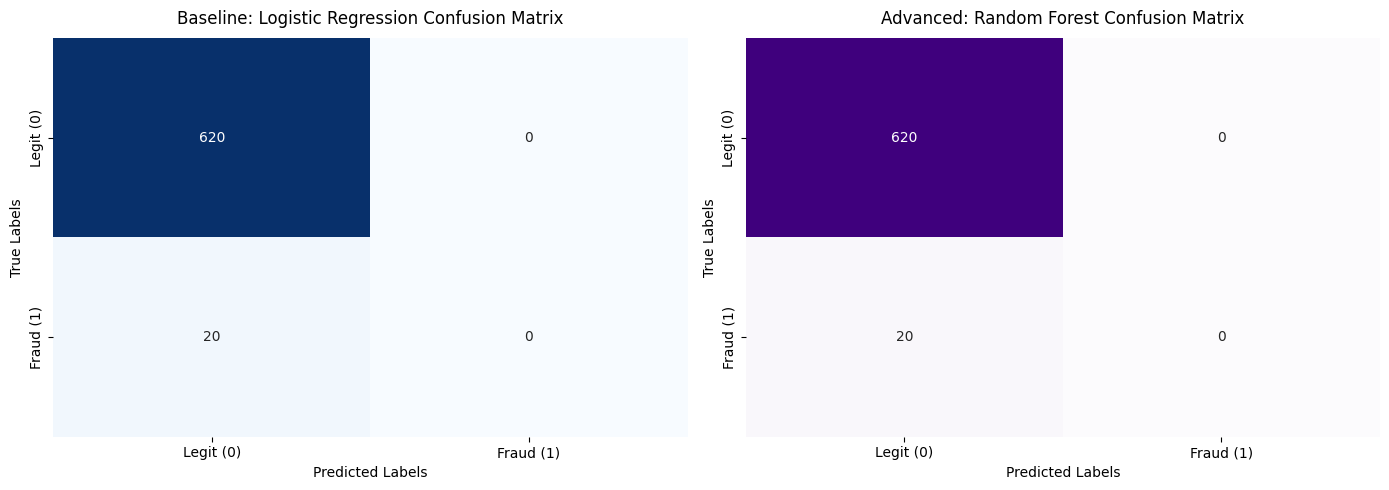

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrices for both models
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Set up side-by-side beautiful plotting canvases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap for Logistic Regression
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'], ax=ax1)
ax1.set_title('Baseline: Logistic Regression Confusion Matrix', fontsize=12, pad=10)
ax1.set_xlabel('Predicted Labels')
ax1.set_ylabel('True Labels')

# 2. Heatmap for Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'], ax=ax2)
ax2.set_title('Advanced: Random Forest Confusion Matrix', fontsize=12, pad=10)
ax2.set_xlabel('Predicted Labels')
ax2.set_ylabel('True Labels')

plt.tight_layout()
# Save the graphic directly into your plots folder for your written report!
plt.savefig('../docs/plots/05_confusion_matrices.png', dpi=300)
plt.show()

## Quality of EDA
### Visual Diagnostics: Class Imbalance, Outliers, Feature Risks, and Missing Data Matrix


In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plot_dir = '../docs/plots/'
os.makedirs(plot_dir, exist_ok=True)

print("Generating the 6 Mandatory Milestone 1 Visualizations\n")

Generating the 6 Mandatory Milestone 1 Visualizations



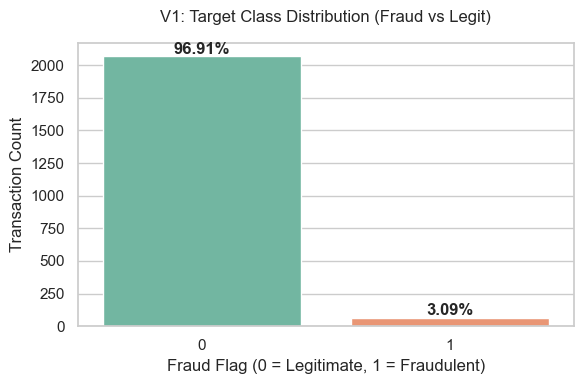

In [8]:
# VISUALIZATION 1: Macro Target Distribution (Class Imbalance Profile)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Fraud_Flag', data=df, hue='Fraud_Flag', palette='Set2', legend=False)
plt.title('V1: Target Class Distribution (Fraud vs Legit)', fontsize=12, pad=15)
plt.xlabel('Fraud Flag (0 = Legitimate, 1 = Fraudulent)')
plt.ylabel('Transaction Count')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '01_target_imbalance.png'), dpi=300)
plt.show()

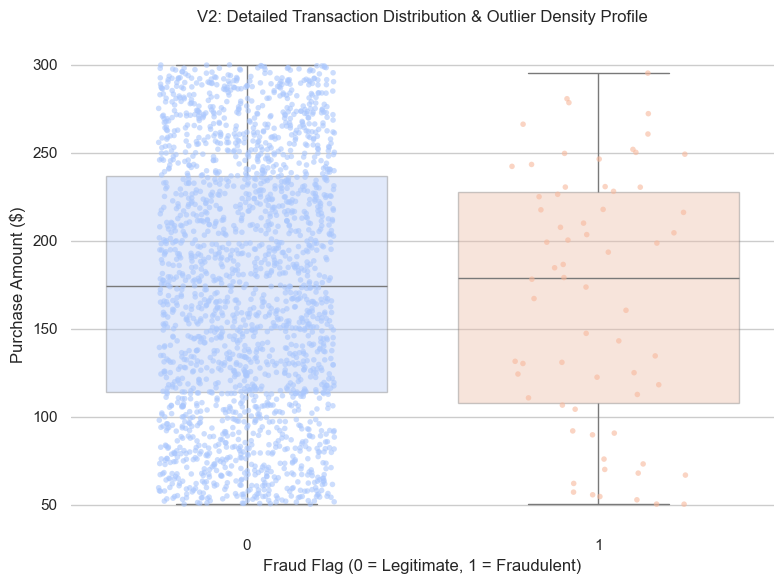

In [9]:
# =========================================================================
# VISUALIZATION 2: Advanced Purchase Amount Outlier Analysis (Box + Strip)
# =========================================================================
plt.figure(figsize=(8, 6))

# 1. Draw the underlying boxes (alpha is moved inside boxprops to prevent the TypeError)
sns.boxplot(
    x='Fraud_Flag', 
    y='Purchase_Amount', 
    data=df, 
    hue='Fraud_Flag', 
    palette='coolwarm', 
    whis=1.5,
    boxprops=dict(alpha=0.4),  # <--- This fixes the version error!
    legend=False
)

# 2. Overlay jittered raw transaction data points to show density distribution
sns.stripplot(
    x='Fraud_Flag', 
    y='Purchase_Amount', 
    data=df, 
    hue='Fraud_Flag',
    palette='coolwarm', 
    alpha=0.6, 
    jitter=0.25, 
    size=4,
    dodge=False,
    legend=False
)

plt.title('V2: Detailed Transaction Distribution & Outlier Density Profile', fontsize=12, pad=15)
plt.xlabel('Fraud Flag (0 = Legitimate, 1 = Fraudulent)')
plt.ylabel('Purchase Amount ($)')

# Clean up styling borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '02_amount_boxplot.png'), dpi=300)
plt.show()

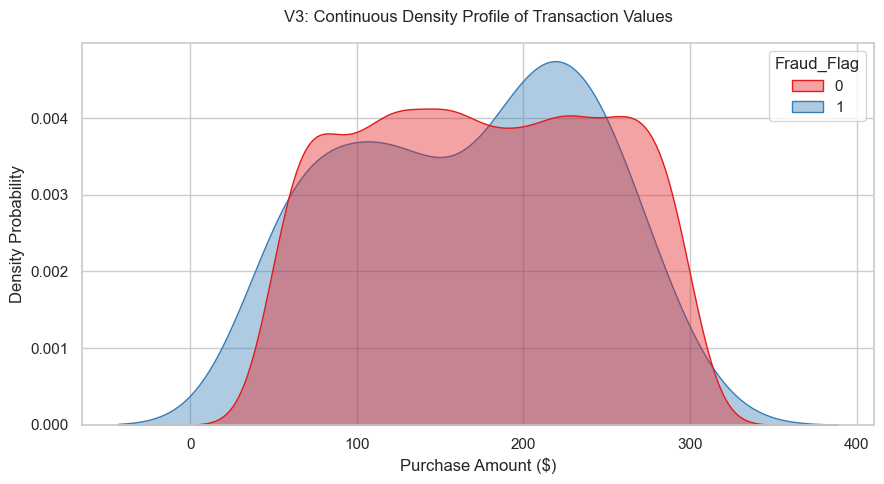

In [10]:
# VISUALIZATION 3: Transaction Value Continuous Density Curves

plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='Purchase_Amount', hue='Fraud_Flag', common_norm=False, fill=True, palette='Set1', alpha=0.4)
plt.title('V3: Continuous Density Profile of Transaction Values', fontsize=12, pad=15)
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Density Probability')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '03_amount_density.png'), dpi=300)
plt.show()

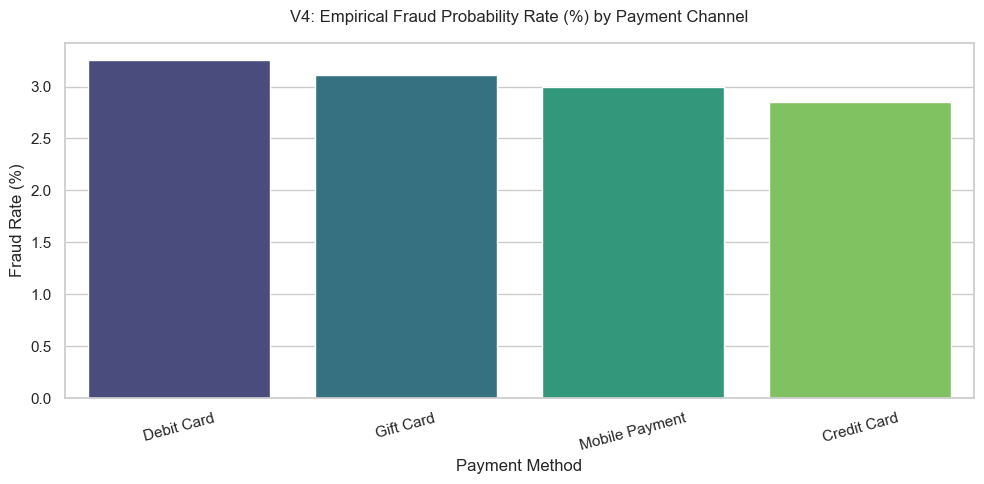

In [11]:
# VISUALIZATION 4: Risk Variance Across Payment Mediums

plt.figure(figsize=(10, 5))
fraud_rates = df.groupby('Payment_Method')['Fraud_Flag'].mean().sort_values(ascending=False) * 100
sns.barplot(x=fraud_rates.index, y=fraud_rates.values, hue=fraud_rates.index, palette='viridis', legend=False)
plt.title('V4: Empirical Fraud Probability Rate (%) by Payment Channel', fontsize=12, pad=15)
plt.xlabel('Payment Method')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '04_payment_fraud_rate.png'), dpi=300)
plt.show()

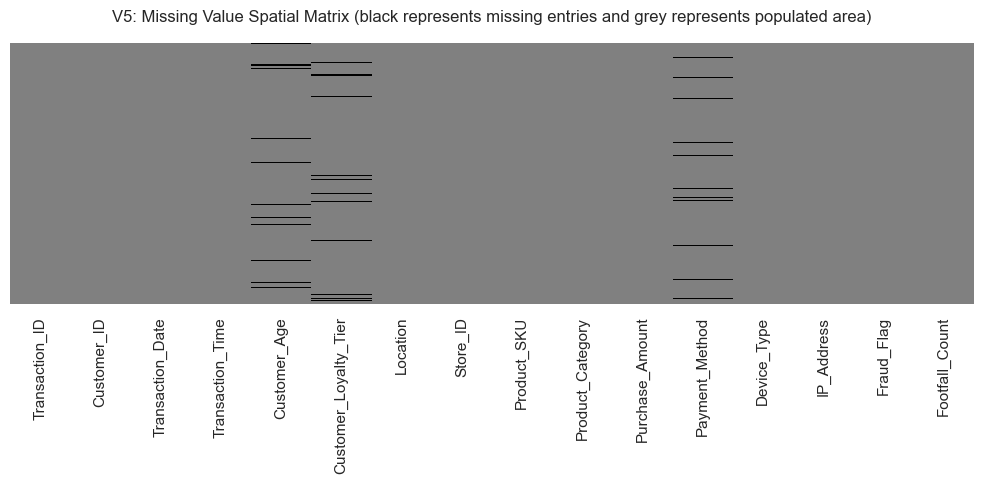

In [16]:
# VISUALIZATION 5: High-Contrast Missing Value Structural Heatmap
plt.figure(figsize=(10, 5))
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['grey', 'black'])
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap=custom_cmap)
plt.title('V5: Missing Value Spatial Matrix (black represents missing entries and grey represents populated area)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '05_missing_matrix.png'), dpi=300)
plt.show()

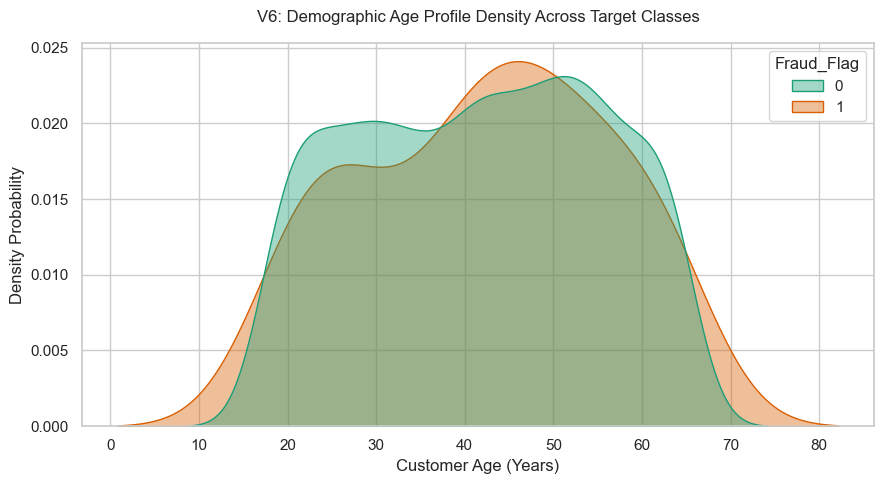

In [13]:
# VISUALIZATION 6: Age Distribution Density of Transaction Profiles

plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='Customer_Age', hue='Fraud_Flag', common_norm=False, fill=True, palette='Dark2', alpha=0.4)
plt.title('V6: Demographic Age Profile Density Across Target Classes', fontsize=12, pad=15)
plt.xlabel('Customer Age (Years)')
plt.ylabel('Density Probability')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '06_age_density.png'), dpi=300)
plt.show()